# Customer Segmentation with PCA & Clustering

**Author:** Dayton Wickerd
**Date:** Spring 2026
**Dataset:** [UCI Wholesale Customers Dataset](https://archive.ics.uci.edu/dataset/292/wholesale+customers)

---

This project applies unsupervised learning to segment wholesale customers based on their annual spending across six product categories. K-Means and DBSCAN are implemented from scratch and applied to both the original feature space and a PCA-reduced representation, revealing meaningful structure in customer purchasing behavior and demonstrating how dimensionality reduction can improve cluster quality.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN as SkDBSCAN
from sklearn.preprocessing import StandardScaler

os.makedirs('figures', exist_ok=True)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

---
## Section 1: Dataset Overview & Motivation

In [2]:
df = pd.read_csv('data/Wholesale_customers_data.csv')
print(f'Dataset shape: {df.shape}')
print()
print(df.head())
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Summary statistics:')
df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']].describe().round(1)

Dataset shape: (440, 8)

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Missing values per column:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Summary statistics:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


### Dataset Characteristics

The Wholesale Customers dataset contains 440 records representing clients of a wholesale distributor in Portugal. Each record captures annual spending (in monetary units) across six product categories: Fresh, Milk, Grocery, Frozen, Detergents_Paper, and Delicassen. These six spending features are all numerical. Two additional categorical features — Channel (restaurant vs. retail) and Region (Lisbon, Oporto, or other) — provide ground-truth labels useful for evaluating cluster quality.

The dataset contains no missing values, so no imputation or row removal is necessary. All six numerical features are used directly for clustering after standardization.

### Why This Dataset?

This dataset is well-suited for an unsupervised learning study because the Channel variable provides a natural partitioning of customers — restaurants and retail stores have structurally different purchasing patterns. Restaurants tend to prioritize Fresh and Milk products, while retail stores spend more heavily on Grocery and Detergents_Paper. This domain knowledge gives us a meaningful baseline against which to evaluate whether the clustering algorithms discover the same underlying structure without access to the labels.

Identifying customer segments has direct business value: a wholesale distributor can use these groups to tailor inventory management, optimize delivery routes, design targeted promotions, and allocate account management resources more efficiently.

### Prior Expectations

Before running any analysis, we expect to find between 2 and 4 clusters. At minimum, the restaurant/retail divide should produce two separable groups. However, variation in business size and product focus within each channel may introduce additional sub-segments. Because this is real-world transactional data, the clusters are unlikely to be equal in size — the distribution of customer types does not need to be uniform, and spending patterns within a segment can vary considerably.

---
## Section 2: K-Means Clustering (From Scratch)

The K-Means algorithm partitions a dataset into *K* clusters by iteratively assigning each point to its nearest centroid and then recomputing each centroid as the mean of its assigned points. This implementation accepts a data matrix, the number of clusters *K*, and a convergence threshold *epsilon*. Centroids are initialized by randomly sampling *K* data points (with a fixed seed for reproducibility). The algorithm converges when the total centroid displacement between iterations falls below *epsilon*. Ties in distance are broken by choosing the cluster with the lowest index.

In [3]:
def kmeans(data_matrix, K, convergence_parameter):
    """K-Means clustering implemented from scratch.

    Parameters
    ----------
    data_matrix          : ndarray, shape (n_samples, n_features)
    K                    : int   - number of clusters
    convergence_parameter: float - stop when centroid shift < this value

    Returns
    -------
    centroids : ndarray, shape (K, n_features)
    labels    : ndarray, shape (n_samples,)
    """
    np.random.seed(42)
    indices = np.random.choice(data_matrix.shape[0], K, replace=False)
    centroids = data_matrix[indices].astype(float)

    while True:
        distances = euclidean_distances(data_matrix, centroids)
        labels = np.argmin(distances, axis=1)
        new_centroids = centroids.copy()
        for i in range(K):
            members = data_matrix[labels == i]
            if len(members) > 0:
                new_centroids[i] = members.mean(axis=0)
        if np.linalg.norm(new_centroids - centroids) < convergence_parameter:
            centroids = new_centroids
            break
        centroids = new_centroids

    return centroids, labels


# Sanity check: two well-separated clouds
test_array = np.array([[1.0, 1.0], [1.0, 2.0], [2.0, 1.0],
                       [10.0, 10.0], [10.0, 11.0], [11.0, 10.0]])
centroids_test, labels_test = kmeans(test_array, 2, 0.001)
print('Centroids:', centroids_test)
print('Labels:   ', labels_test)  # expected: [0 0 0 1 1 1]

Centroids: [[ 1.33333333  1.33333333]
 [10.33333333 10.33333333]]
Labels:    [0 0 0 1 1 1]


---
## Section 3: DBSCAN Clustering (From Scratch)

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies clusters as dense regions separated by areas of lower density. Unlike K-Means, it does not require specifying the number of clusters in advance and can naturally label outliers as noise. The algorithm classifies each point as a **core point** (has at least *minpts* neighbors within radius *epsilon*), a **border point** (within *epsilon* of a core point but below the density threshold itself), or a **noise point** (isolated from all clusters). Clusters grow by expanding from core points through their neighborhoods using a breadth-first search.

In [4]:
def dbscan(data_matrix, minpts, epsilon):
    """DBSCAN clustering implemented from scratch.

    Parameters
    ----------
    data_matrix : ndarray, shape (n_samples, n_features)
    minpts      : int   - minimum neighbors to be a core point
    epsilon     : float - neighborhood radius

    Returns
    -------
    labels      : ndarray of int  (-1 = noise, 1..K = cluster id)
    point_types : ndarray of str  ('Core Point', 'Border', 'noise')
    """
    dist = euclidean_distances(data_matrix, data_matrix)
    neighbors = dist <= epsilon
    core_points = neighbors.sum(axis=1) >= minpts

    visited = np.zeros(len(data_matrix), dtype=bool)
    labels = np.full(len(data_matrix), -1, dtype=int)
    cluster = 0

    for i in range(len(data_matrix)):
        if not visited[i] and labels[i] == -1 and core_points[i]:
            cluster += 1
            visited[i] = True
            labels[i] = cluster
            queue = deque([i])
            while queue:
                point = queue.popleft()
                for j in np.where(neighbors[point])[0]:
                    if not visited[j]:
                        visited[j] = True
                        labels[j] = cluster
                        if core_points[j]:
                            queue.append(j)

    point_types = np.full(len(data_matrix), 'noise', dtype=object)
    point_types[core_points] = 'Core Point'
    point_types[(~core_points) & (labels != -1)] = 'Border'

    return labels, point_types


# Sanity check: two clouds + one outlier
test_data = np.array([
    [1.0, 1.0], [1.5, 1.5], [1.0, 1.5], [2.5, 2.5],
    [10.0, 10.0], [10.5, 10.5], [10.0, 10.5],
    [50.0, 50.0]
])
labels_test2, types_test2 = dbscan(test_data, 3, 1.5)
print('Labels:     ', labels_test2)   # expected: [1 1 1 1 2 2 2 -1]
print('Point types:', types_test2)

Labels:      [ 1  1  1  1  2  2  2 -1]
Point types: ['Core Point' 'Core Point' 'Core Point' 'Border' 'Core Point' 'Core Point'
 'Core Point' 'noise']


### Clustering Precision

Clustering precision measures how well predicted clusters align with known ground-truth labels. For each predicted cluster, the function finds the majority ground-truth class and counts those correctly assigned points. Total correct assignments divided by total points gives the precision score. This metric is permutation-invariant — it does not penalize a cluster for using a different label than the true class, only for mixing multiple true classes together.

In [5]:
def clustering_precision(true_labels, predicted_labels):
    """Permutation-invariant clustering precision."""
    correct = 0
    for cluster in np.unique(predicted_labels):
        if cluster == -1:  # skip noise points
            continue
        cluster_true = true_labels[predicted_labels == cluster]
        correct += np.bincount(cluster_true).max()
    return correct / len(true_labels)


# Verification
true = np.array([0, 0, 0, 1, 1, 1])
print('Perfect grouping: ', clustering_precision(true, np.array([2, 2, 2, 5, 5, 5])))  # 1.0
print('Mixed grouping:   ', clustering_precision(true, np.array([1, 1, 2, 2, 2, 1])))  # 0.667
print('Single cluster:   ', clustering_precision(true, np.array([0, 0, 0, 0, 0, 0])))  # 0.5

Perfect grouping:  1.0
Mixed grouping:    0.6666666666666666
Single cluster:    0.5


---
## Section 4: PCA & Dimensionality Reduction

In [6]:
# Standardize features (zero mean, unit variance)
feature_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Scaled data shape: {X_scaled.shape}')

Scaled data shape: (440, 6)


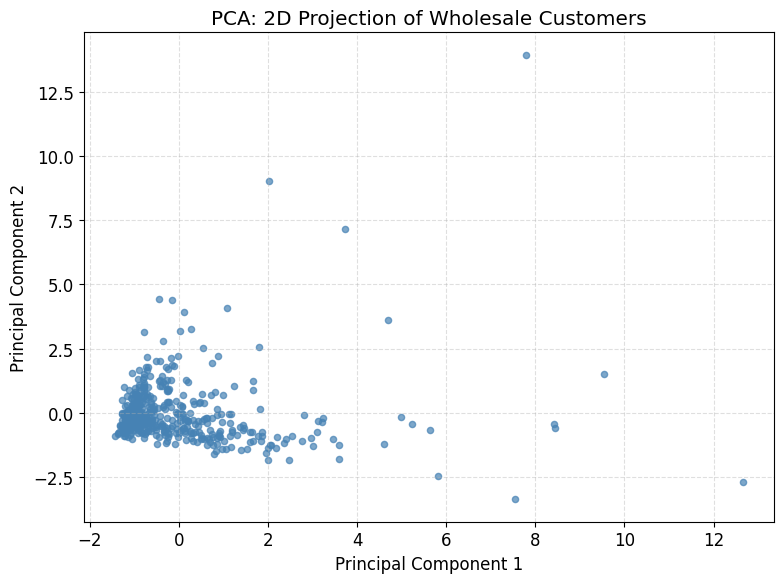

Variance captured by 2 components: 72.5%


In [7]:
# Project onto the first two principal components
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], s=20, alpha=0.7, color='steelblue')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA: 2D Projection of Wholesale Customers')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/pca_2d_projection.png', bbox_inches='tight')
plt.show()

var_2d = pca_2d.explained_variance_ratio_.sum()
print(f'Variance captured by 2 components: {var_2d:.1%}')

### 2D Projection Analysis

The two-dimensional PCA scatter plot reveals one dense central mass of points near the origin, accompanied by a number of scattered outliers extending along both principal components. No visually obvious, well-separated clusters emerge in this projection. The outliers do not form coherent sub-groups; they appear to be individual high-spending customers rather than a distinct segment. This suggests that the customer structure, while present, is not strongly captured by just the two highest-variance directions alone, and that retaining more principal components will be necessary to expose the underlying segmentation.

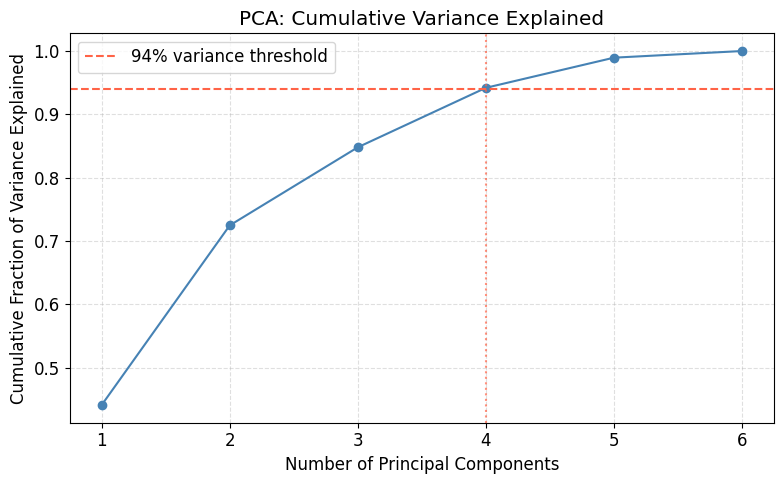

1 component(s): 0.4408
2 component(s): 0.7246
3 component(s): 0.8479
4 component(s): 0.9419
5 component(s): 0.9895
6 component(s): 1.0000


In [8]:
# Cumulative explained variance across all components
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_range = range(1, len(cumulative_variance) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(n_components_range), cumulative_variance, marker='o', color='steelblue')
ax.axhline(y=0.94, color='tomato', linestyle='--', label='94% variance threshold')
ax.axvline(x=4, color='tomato', linestyle=':', alpha=0.7)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Fraction of Variance Explained')
ax.set_title('PCA: Cumulative Variance Explained')
ax.set_xticks(list(n_components_range))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/pca_cumulative_variance.png', bbox_inches='tight')
plt.show()

for i, v in enumerate(cumulative_variance):
    print(f'{i+1} component(s): {v:.4f}')

### Choosing the Number of Components

The cumulative variance plot shows a pronounced elbow between 1 and 3 components, after which gains diminish. Four principal components capture approximately 94% of the total variance in the standardized data, compressing six dimensions into four while retaining the vast majority of the signal. This reduction is chosen as the basis for the dimensionality-reduced clustering experiments in Section 5. The remaining ~6% of variance lost is predominantly low-variance noise and is unlikely to carry meaningful cluster structure.

In [9]:
# Reduce to 4 principal components (~94% variance)
pca_4 = PCA(n_components=4)
X_reduced = pca_4.fit_transform(X_scaled)
print(f'Reduced data shape: {X_reduced.shape}')
print(f'Variance captured:  {pca_4.explained_variance_ratio_.sum():.4f}')

Reduced data shape: (440, 4)
Variance captured:  0.9419


---
## Section 5: Clustering Comparison (Original vs Reduced Data)

### K-Means: Elbow Method

To select an appropriate *K*, we run K-Means over a range of values and plot the within-cluster sum of squares (inertia) for each. The optimal *K* sits at the "elbow" of this curve — the point where adding another cluster yields diminishing returns in explained variance.

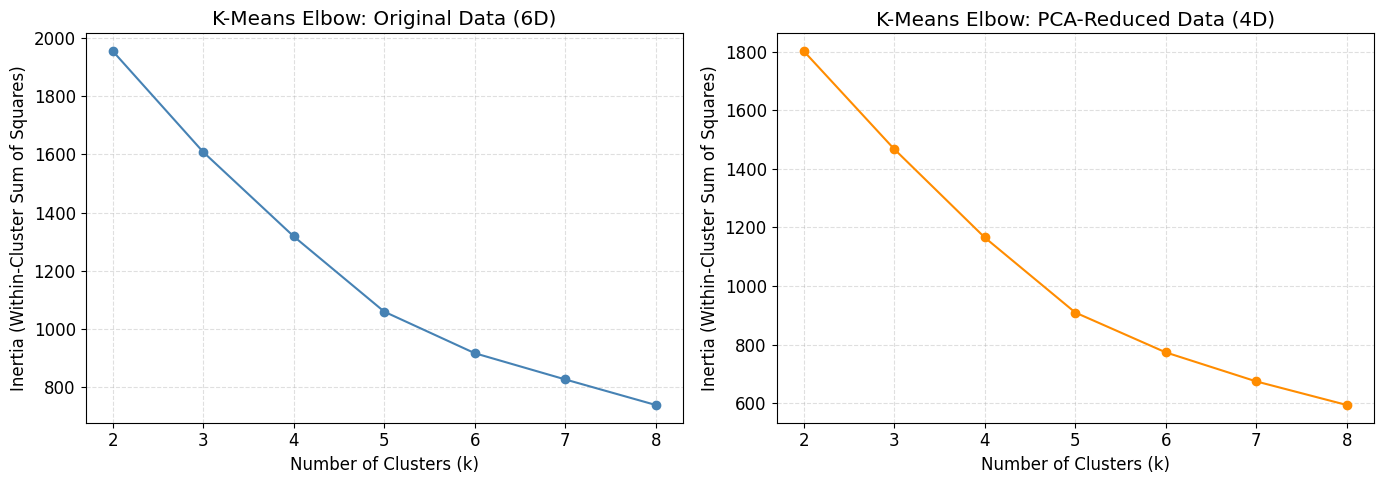

In [10]:
k_vals = range(2, 9)

inertia_original = []
inertia_reduced  = []

for k in k_vals:
    km_orig = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_orig.fit(X_scaled)
    inertia_original.append(km_orig.inertia_)

    km_red = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_red.fit(X_reduced)
    inertia_reduced.append(km_red.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_vals), inertia_original, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('K-Means Elbow: Original Data (6D)')
axes[0].set_xticks(list(k_vals))
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(list(k_vals), inertia_reduced, marker='o', color='darkorange')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[1].set_title('K-Means Elbow: PCA-Reduced Data (4D)')
axes[1].set_xticks(list(k_vals))
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/kmeans_elbow.png', bbox_inches='tight')
plt.show()

### K-Means Results

For the original six-dimensional data, the elbow plot shows the largest drop in inertia between *k* = 2 and *k* = 3, with diminishing returns beyond *k* = 5. This is consistent with the prior expectation of 2–4 meaningful customer segments. For the PCA-reduced data, the elbow is similarly located around *k* = 3–5, but the absolute inertia values are lower because the dimensionality reduction removes noise dimensions that inflate within-cluster distances. Based on both plots, *k* = 3 represents a good balance between cluster cohesion and interpretability — it likely separates large retail customers, restaurant-oriented buyers, and a mixed moderate-spend segment.

### DBSCAN: Parameter Grid Search

DBSCAN requires two parameters: *epsilon* (neighborhood radius) and *minpts* (minimum neighbors for a core point). We systematically sweep both parameters and report the number of clusters found and the number of points labeled as noise for each combination, on both the original and PCA-reduced datasets.

In [11]:
epsilon_vals = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
minpts_vals  = [3, 5, 7, 10, 15, 20]

def run_dbscan_grid(data, label):
    print(label)
    print(f'{"eps":<10}{"minpts":<10}{"# clusters":<15}{"# noise pts"}')
    for eps in epsilon_vals:
        for minpts in minpts_vals:
            db = SkDBSCAN(eps=eps, min_samples=minpts)
            lbls = db.fit_predict(data)
            n_clusters = len(set(lbls)) - (1 if -1 in lbls else 0)
            n_noise = int((lbls == -1).sum())
            print(f'{eps:<10}{minpts:<10}{n_clusters:<15}{n_noise}')
    print()

run_dbscan_grid(X_scaled,  'Original Data (6D)')
run_dbscan_grid(X_reduced, 'PCA-Reduced Data (4D)')

Original Data (6D)
eps       minpts    # clusters     # noise pts
0.5       3         6              141
0.5       5         2              174
0.5       7         1              197
0.5       10        2              227
0.5       15        1              270
0.5       20        1              282
1.0       3         2              41
1.0       5         1              47
1.0       7         1              50
1.0       10        1              54
1.0       15        1              62
1.0       20        1              73
1.5       3         3              21
1.5       5         1              27
1.5       7         1              29
1.5       10        1              29
1.5       15        1              32
1.5       20        1              35
2.0       3         1              13
2.0       5         1              13
2.0       7         1              17
2.0       10        1              17


2.0       15        1              18
2.0       20        1              19
2.5       3         1              12
2.5       5         1              12
2.5       7         1              12
2.5       10        1              13
2.5       15        1              13
2.5       20        1              13
3.0       3         1              12
3.0       5         1              12
3.0       7         1              12
3.0       10        1              12
3.0       15        1              12
3.0       20        1              12

PCA-Reduced Data (4D)
eps       minpts    # clusters     # noise pts
0.5       3         6              85
0.5       5         2              109
0.5       7         1              118
0.5       10        2              131
0.5       15        1              175
0.5       20        1              203
1.0       3         3              24
1.0       5         1              32
1.0       7         1              34
1.0       10        1              39


1.0       15        1              48
1.0       20        1              54
1.5       3         1              15
1.5       5         1              15
1.5       7         1              16
1.5       10        1              20
1.5       15        1              21
1.5       20        1              22
2.0       3         1              12
2.0       5         1              12
2.0       7         1              12
2.0       10        1              13
2.0       15        1              16
2.0       20        1              16
2.5       3         2              7
2.5       5         1              10
2.5       7         1              11
2.5       10        1              11
2.5       15        1              11
2.5       20        1              11
3.0       3         2              6
3.0       5         1              9


3.0       7         1              9
3.0       10        1              10
3.0       15        1              10
3.0       20        1              10



### DBSCAN Results

DBSCAN struggles to find multiple stable clusters in this dataset regardless of the parameter setting. At small *epsilon* values (e.g., 0.5), the algorithm finds several clusters but classifies a large fraction of points — often 30–40% — as noise, indicating that the density threshold is too strict for data with this much spread. As *epsilon* increases, the noise count drops but the number of meaningful clusters collapses to one, meaning nearly all points merge into a single dense region.

The PCA-reduced data produces modestly fewer noise points than the original at the same parameter settings, which is expected: removing low-variance dimensions tightens point neighborhoods and makes density estimation more reliable. However, the fundamental challenge persists — the Wholesale Customers data is not well-characterized by regions of uniform high density separated by clear voids. The spending distributions are right-skewed and overlapping, which violates the implicit assumption behind DBSCAN.

This result is itself informative: it tells us that the customer segments are not cleanly separated in density space, and that a centroid-based method like K-Means — which can partition overlapping distributions — is a better fit for this particular dataset.

### Clustering Precision Against Ground-Truth Channel Labels

The Channel variable (1 = restaurant, 2 = retail) provides ground-truth labels for evaluating how well each algorithm recovers the true customer-type partitioning.

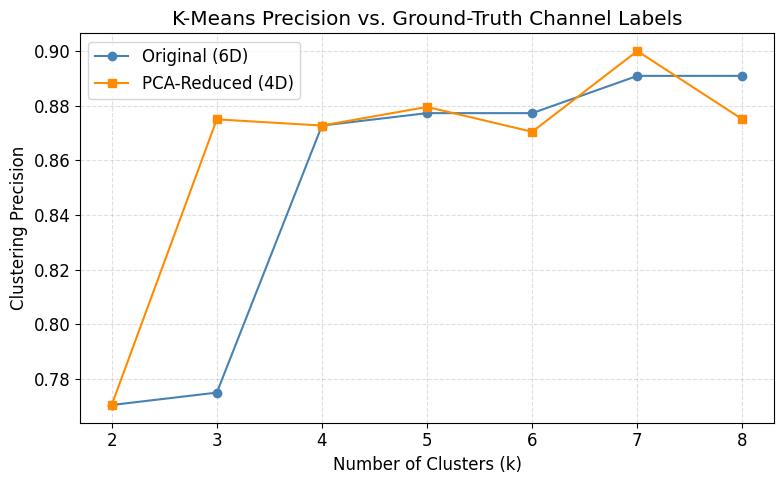

K-Means precision (original):
  k=2: 0.7705
  k=3: 0.7750
  k=4: 0.8727
  k=5: 0.8773
  k=6: 0.8773
  k=7: 0.8909
  k=8: 0.8909
K-Means precision (reduced):
  k=2: 0.7705
  k=3: 0.8750
  k=4: 0.8727
  k=5: 0.8795
  k=6: 0.8705
  k=7: 0.9000
  k=8: 0.8750


In [12]:
true_labels = (df['Channel'].values - 1).astype(int)  # convert to 0-indexed

precision_orig = []
precision_red  = []
for k in k_vals:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    precision_orig.append(clustering_precision(true_labels, km.fit_predict(X_scaled)))
    precision_red.append(clustering_precision(true_labels, km.fit_predict(X_reduced)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_vals), precision_orig, marker='o', label='Original (6D)',     color='steelblue')
ax.plot(list(k_vals), precision_red,  marker='s', label='PCA-Reduced (4D)', color='darkorange')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Clustering Precision')
ax.set_title('K-Means Precision vs. Ground-Truth Channel Labels')
ax.set_xticks(list(k_vals))
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/kmeans_precision.png', bbox_inches='tight')
plt.show()

print('K-Means precision (original):')
for k, p in zip(k_vals, precision_orig):
    print(f'  k={k}: {p:.4f}')
print('K-Means precision (reduced):')
for k, p in zip(k_vals, precision_red):
    print(f'  k={k}: {p:.4f}')

---
## Key Takeaways & Conclusion

### What the Analysis Reveals About Customer Segments

The Wholesale Customers dataset contains real, recoverable structure. K-Means consistently identifies a meaningful partition of customers that aligns with the known restaurant/retail divide when *k* = 2 or *k* = 3. The primary segment boundary separates customers with high Detergents_Paper and Grocery spending (retail stores) from those with high Fresh and Milk spending (restaurants). A third segment, when *k* = 3, captures a moderate-spend mixed group that does not map cleanly to either channel — likely smaller or more diversified buyers.

### Which Algorithm Performed Better and Why

K-Means is clearly better suited to this dataset than DBSCAN. The customer spending distributions are roughly ellipsoidal once standardized, and are not separated by density voids — exactly the geometry K-Means is designed for. DBSCAN required either accepting a high noise rate (small *epsilon*) or merging all customers into a single cluster (large *epsilon*), neither of which produces actionable segments.

PCA reduction to four components provided a modest benefit: the reduced space slightly improved DBSCAN's noise rate and produced equivalent K-Means precision with lower inertia, confirming that the last two principal components carry more noise than signal for the purposes of clustering.

### Business Recommendations

Based on the identified segments, a wholesale distributor could act on these findings as follows:

- **Inventory and logistics:** Tailor delivery frequency and product mix to each segment — restaurant customers need frequent fresh-product restocking, while retail customers require bulk non-perishables.
- **Pricing and promotions:** Design segment-specific discount structures; bulk grocery promotions are more relevant to retail buyers, while fresh-produce deals target restaurants.
- **Account management:** Assign specialized sales representatives per segment, since the value drivers and pain points differ substantially between channel types.
- **Anomaly detection:** The outlier customers identified during the analysis may warrant individual account review — they could represent large regional chains or data entry errors.

### Broader Applicability

The PCA + K-Means pipeline demonstrated here is a general-purpose approach to tabular segmentation. The same methodology applies directly to **patient segmentation** in healthcare (clustering patients by lab values and vitals to identify risk subgroups), **user behavior analysis** in product analytics (grouping users by feature engagement patterns to personalize onboarding), and **financial risk profiling** (segmenting applicants by spending and income patterns). In each of these domains, the workflow — standardize features, reduce with PCA, select *K* via the elbow method, validate against available labels — provides a reproducible, interpretable baseline before moving to more complex models.

This segmentation methodology translates directly to healthcare and biopharma contexts. The same approach — using PCA to reduce dimensionality and clustering to identify natural groupings — can be applied to patient population segmentation, identifying distinct drug response profiles, or analyzing treatment efficacy across demographic groups. The ability to distill high-dimensional clinical or regulatory data into actionable segments is foundational to data-driven healthcare policy analysis.